In [1]:
#!pip install pymc==4.1.4
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
from scipy.optimize import minimize

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).


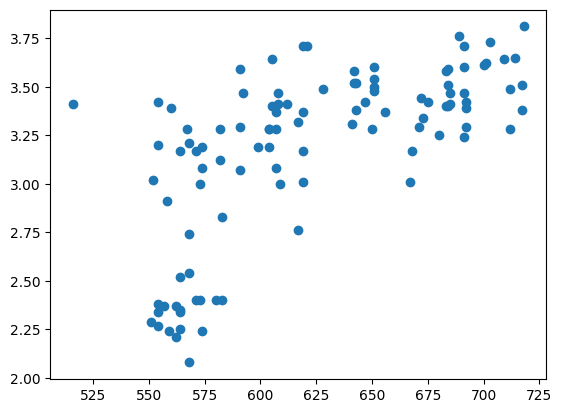

In [3]:
from google.colab import drive
drive.mount('/drive')
data = np.loadtxt('/drive/MyDrive/COM3031/week4/SAT_data.csv',delimiter=',',skiprows=1)
X = data[:,0]
y = data[:,2]
plt.scatter(X,y)
plt.show()
#data

ϵ is not the intercept. It’s a random error/noise term that captures deviations from the regression line.

In [ ]:
# First part

In [4]:
def likelihood(theta,*args):
    b = theta
    L = np.sum(np.log(1/np.sqrt((2*np.pi*sigma_y**2))) - 1/(2*sigma_y**2)*(y - b*X)**2)
    return -L

In [7]:
sigma_y = 0.445 # given sigma
bounds = [(-10,10)]
results = minimize(likelihood,[1],args = (y,X,sigma_y),bounds = bounds,method = 'L-BFGS-B')
b_mle = float(results.x)
print("Q1(1) MLE b =", b_mle)

Q1(1) MLE b = 0.005095322199850486


/tmp/ipython-input-1054251041.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_mle = float(results.x)


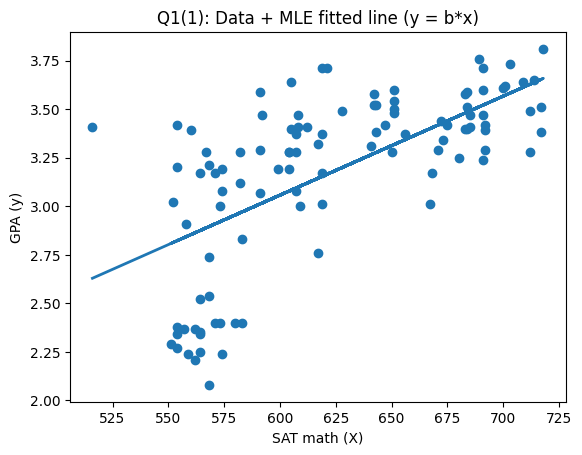

In [8]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, b_mle * X, linewidth=2)
plt.title("Q1(1): Data + MLE fitted line (y = b*x)")
plt.xlabel("SAT math (X)")
plt.ylabel("GPA (y)")
plt.show()

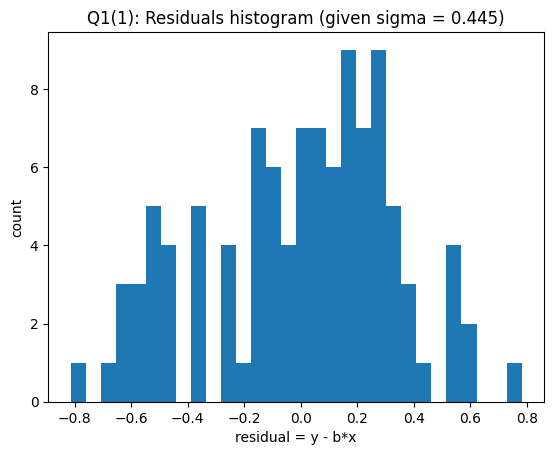

In [9]:
residuals = y - b_mle * X

plt.figure()
plt.hist(residuals, bins=30)
plt.title(f"Q1(1): Residuals histogram (given sigma = {sigma_y})")
plt.xlabel("residual = y - b*x")
plt.ylabel("count")
plt.show()

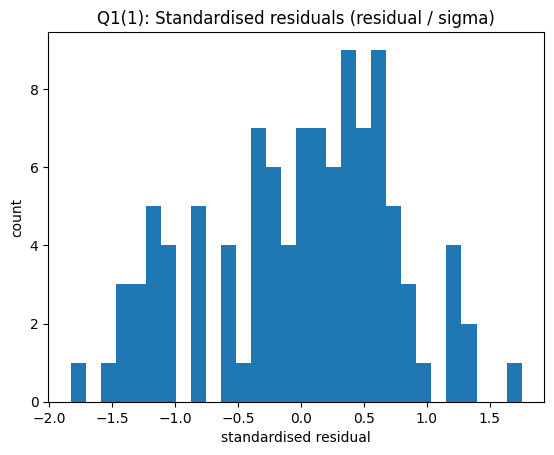

In [10]:
std_residuals = residuals / sigma_y

plt.figure()
plt.hist(std_residuals, bins=30)
plt.title("Q1(1): Standardised residuals (residual / sigma)")
plt.xlabel("standardised residual")
plt.ylabel("count")
plt.show()

Output()

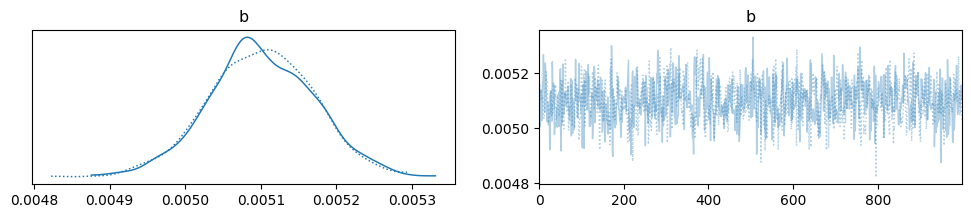

In [12]:
# Second part

sigma_prior = 10 # sigma in prior distribution
base_model = pm.Model()
with base_model:
    b = pm.Normal('b',0,sigma=sigma_prior)
    likelihood = pm.Normal('y',mu=b*X,sigma=sigma_y,observed=y)
    trace = pm.sample(1000)
pm.plot_trace(trace)
plt.show()

#pm.summary(trace)

In [13]:
summary = pm.summary(trace)
print(summary.loc["b", ["mean", "sd", "hdi_3%", "hdi_97%"]])

mean       0.005
sd         0.000
hdi_3%     0.005
hdi_97%    0.005
Name: b, dtype: float64


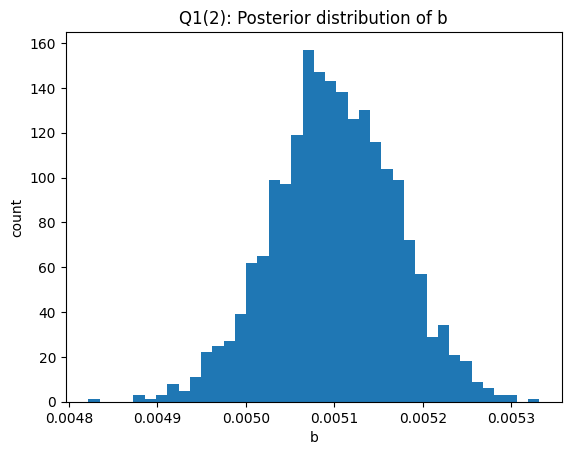

Posterior mean: 0.005100007676171581
95% credible interval: [0.0049606  0.00523643]


In [14]:
b_samples = trace.posterior["b"].values.reshape(-1)

plt.figure()
plt.hist(b_samples, bins=40)
plt.title("Q1(2): Posterior distribution of b")
plt.xlabel("b")
plt.ylabel("count")
plt.show()

print("Posterior mean:", np.mean(b_samples))
print("95% credible interval:", np.quantile(b_samples, [0.025, 0.975]))


/tmp/ipython-input-3599968455.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_mle = float(results.x)


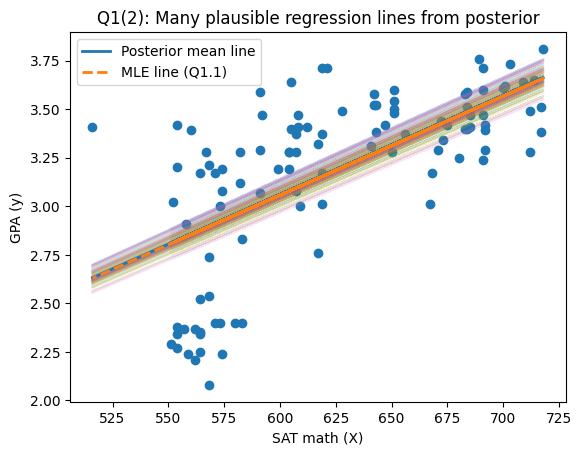

In [17]:
#mle from Q1(1)
b_mle = float(results.x)


plt.figure()
plt.scatter(X, y)

# Draw 50 lines
for b in np.random.choice(b_samples, size=50, replace=False):
    plt.plot(X, b * X, alpha=0.2)

# post mean line + MLE Line
plt.plot(X, np.mean(b_samples) * X, linewidth=2, label="Posterior mean line")
plt.plot(X, b_mle * X, linewidth=2, linestyle="--", label="MLE line (Q1.1)")

plt.title("Q1(2): Many plausible regression lines from posterior")
plt.xlabel("SAT math (X)")
plt.ylabel("GPA (y)")
plt.legend()
plt.show()


In [ ]:
# Third part

In [18]:
def likelihood_(theta,*args):
    b = theta[0]
    sigma_y = theta[1]
    L = np.sum(np.log(1/np.sqrt((2*np.pi*sigma_y**2))) - 1/(2*sigma_y**2)*(y - b*X)**2 )
    return -L

In [20]:
bounds = [(-10,10),(0.0001,10)]
results = minimize(likelihood_,[1,3],args = (y,X),bounds = bounds,method = 'L-BFGS-B')

b_hat, sigma_hat = results.x
print("Q1(3) MLE b =", b_hat)
print("Q1(3) MLE sigma =", sigma_hat)

Q1(3) MLE b = 0.0050953218961699385
Q1(3) MLE sigma = 0.33401957204479876


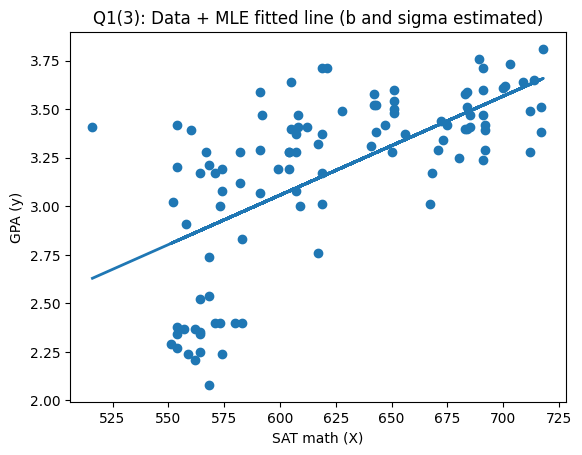

In [21]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, b_hat * X, linewidth=2)
plt.title("Q1(3): Data + MLE fitted line (b and sigma estimated)")
plt.xlabel("SAT math (X)")
plt.ylabel("GPA (y)")
plt.show()


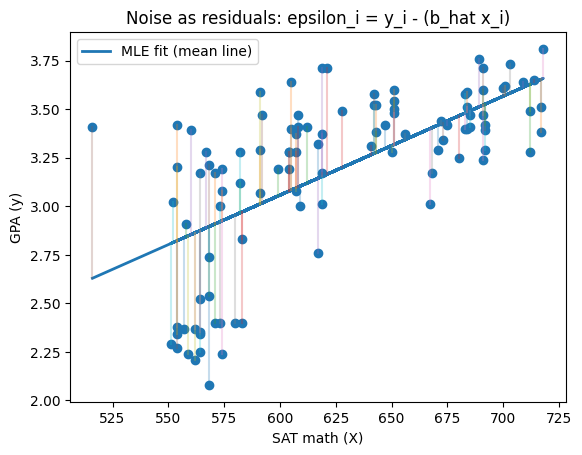

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X, y)

y_fit = b_hat * X
plt.plot(X, y_fit, linewidth=2, label="MLE fit (mean line)")

#  error to mean line
for xi, yi, yfi in zip(X, y, y_fit):
    plt.plot([xi, xi], [yfi, yi], alpha=0.25)

plt.title("Noise as residuals: epsilon_i = y_i - (b_hat x_i)")
plt.xlabel("SAT math (X)")
plt.ylabel("GPA (y)")
plt.legend()
plt.show()


Output()

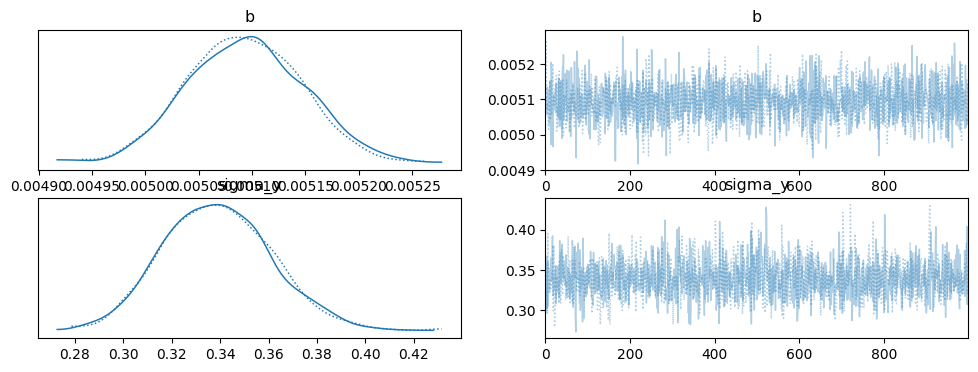

In [23]:
# Fourth part
sigma_prior = 10 # sigma in prior distribution
base_model = pm.Model()
with base_model:
    b = pm.Normal('b',0,sigma=sigma_prior)
    #standard deviation must >= 0
    sigma_y = pm.HalfNormal('sigma_y',sigma = 4)
    likelihood = pm.Normal('y',mu=b*X,sigma=sigma_y,observed=y)
    trace = pm.sample(1000)
pm.plot_trace(trace)
plt.show()

#pm.summary(trace)

In [24]:
summary = pm.summary(trace)
print(summary.loc[["b", "sigma_y"], ["mean", "sd", "hdi_3%", "hdi_97%"]])


          mean     sd  hdi_3%  hdi_97%
b        0.005  0.000   0.005    0.005
sigma_y  0.339  0.023   0.297    0.382


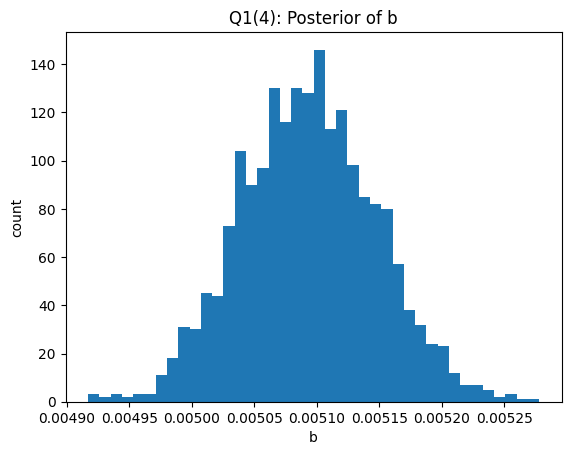

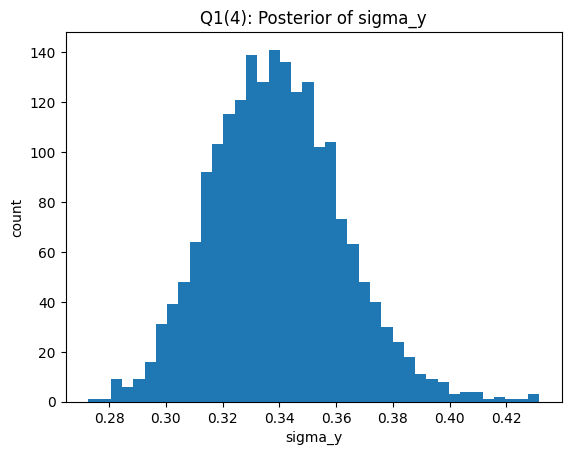

In [25]:
b_samples = trace.posterior["b"].values.reshape(-1)
s_samples = trace.posterior["sigma_y"].values.reshape(-1)

plt.figure()
plt.hist(b_samples, bins=40)
plt.title("Q1(4): Posterior of b")
plt.xlabel("b")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(s_samples, bins=40)
plt.title("Q1(4): Posterior of sigma_y")
plt.xlabel("sigma_y")
plt.ylabel("count")
plt.show()

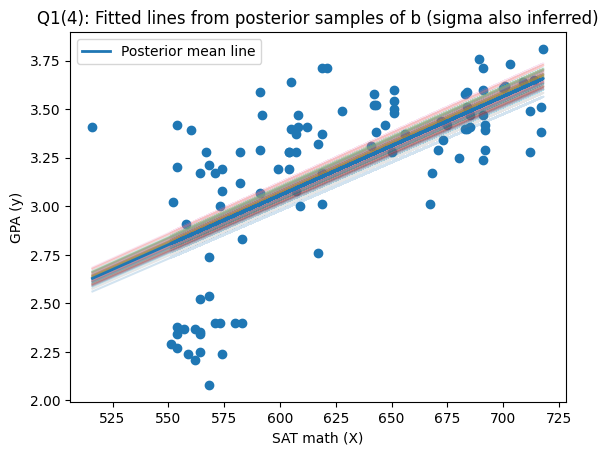

In [27]:
b_samples = trace.posterior["b"].values.reshape(-1)

plt.figure()
plt.scatter(X, y)

for b in np.random.choice(b_samples, size=50, replace=False):
    plt.plot(X, b*X, alpha=0.2)

plt.plot(X, np.mean(b_samples)*X, linewidth=2, label="Posterior mean line")

plt.title("Q1(4): Fitted lines from posterior samples of b (sigma also inferred)")
plt.xlabel("SAT math (X)")
plt.ylabel("GPA (y)")
plt.legend()
plt.show()



We are given the linear model:

$$
y_i = bX_i + \varepsilon.
$$

where the error term follows a normal distribution:

$$
\varepsilon \sim \mathcal{N}(0, \sigma^2).
$$

By a **fundamental property of normal distributions**:
- If $ Z \sim \mathcal{N}(\mu, \sigma^2) $, then adding a constant \( c \) preserves normality:

  $$
  Z + c \sim \mathcal{N}(\mu + c, \sigma^2).
  $$

In our case:
- $ bX_i $ is a deterministic term (not random), so it simply shifts the mean.
- $ \varepsilon $ is the random term, and it follows a normal distribution.
- Therefore, $ y_i $ remains normally distributed:

  $$
  y_i \sim \mathcal{N}(bX_i, \sigma^2).
  $$

**We assume $ y_i $ follows a normal distribution because it is derived from a normal error term.**